# Exploratory Data Analysis (EDA)

The purpose of this notebook is to explore the cleaned CMS hospital datasets, identify patterns, evaluate data quality after cleaning, and discover relationships between variables that may help predict Hospital Overall Rating.

# Measure-Level Data Inspection

The Hospital General Information dataset contains one row per hospital, while the HCAHPS, infection, mortality, and readmission datasets contain multiple rows per hospital. Each row represents a separate reported quality measure. These datasets must therefore be inspected and reshaped before they can be merged into a hospital-level analytical dataset.

# Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project Paths

In [2]:
ROOT_DIR = Path.cwd().parent

INTERIM_DIR = ROOT_DIR / "data" / "interim"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

print(ROOT_DIR)
print(INTERIM_DIR)
print(PROCESSED_DIR)

c:\Repos\capstone-hospital-quality
c:\Repos\capstone-hospital-quality\data\interim
c:\Repos\capstone-hospital-quality\data\processed


# Load Datasets

In [3]:
hospital_general = pd.read_csv(INTERIM_DIR / "hospital_general_clean.csv")
hcahps = pd.read_csv(INTERIM_DIR / "hcahps_clean.csv")
hospital_infections = pd.read_csv(INTERIM_DIR / "hospital_infections_clean.csv")
hospital_mortality = pd.read_csv(INTERIM_DIR / "hospital_mortality_clean.csv")
hospital_readmissions = pd.read_csv(INTERIM_DIR / "hospital_readmissions_clean.csv")

C:\Users\fuemm\AppData\Local\Temp\ipykernel_28648\3844072297.py:2: DtypeWarning: Columns (0: patient_survey_star_rating_footnote, 1: hcahps_answer_percent_footnote, 2: number_of_completed_surveys_footnote, 3: survey_response_rate_percent_footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  hcahps = pd.read_csv(INTERIM_DIR / "hcahps_clean.csv")
C:\Users\fuemm\AppData\Local\Temp\ipykernel_28648\3844072297.py:5: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  hospital_readmissions = pd.read_csv(INTERIM_DIR / "hospital_readmissions_clean.csv")


In [4]:
datasets = {
    "Hospital General": hospital_general,
    "HCAHPS": hcahps,
    "Infections": hospital_infections,
    "Mortality": hospital_mortality,
    "Readmissions": hospital_readmissions,
}

# Dataset-Level Overview

In [5]:
measure_summary = []

for name, df in datasets.items():
    unique_hospitals = df["facility_id"].nunique()

    measure_summary.append(
        {
            "dataset": name,
            "rows": len(df),
            "unique_hospitals": unique_hospitals,
            "rows_per_hospital": len(df) / unique_hospitals,
        }
    )

measure_summary_df = pd.DataFrame(measure_summary)
display(measure_summary_df)

,dataset,rows,unique_hospitals,rows_per_hospital
0,Hospital General,5432,5432,1.0
1,HCAHPS,325856,4792,68.0
2,Infections,172512,4792,36.0
3,Mortality,95840,4792,20.0
4,Readmissions,67088,4792,14.0


### Observations
To achieve the main purpose of analyzing Overall Hospital Rating, we need to ensure the datasets are measured equally. While Hospital General has 1 row per hospital, all other datasets contain multiple rows per hospital. I will need to inspect these a bit further before moving on.

# Inspect columns of each measure-level dataset

In [6]:
measure_datasets = {
    "HCAHPS": hcahps,
    "Infections": hospital_infections,
    "Mortality": hospital_mortality,
    "Readmissions": hospital_readmissions,
}

for name, df in measure_datasets.items():
    print("=" * 70)
    print(name)
    print(df.columns.tolist())

HCAHPS
['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'hcahps_measure_id', 'hcahps_question', 'hcahps_answer_description', 'patient_survey_star_rating', 'patient_survey_star_rating_footnote', 'hcahps_answer_percent', 'hcahps_answer_percent_footnote', 'hcahps_linear_mean_value', 'number_of_completed_surveys', 'number_of_completed_surveys_footnote', 'survey_response_rate_percent', 'survey_response_rate_percent_footnote', 'start_date', 'end_date']
Infections
['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'measure_id', 'measure_name', 'compared_to_national', 'score', 'footnote', 'start_date', 'end_date']
Mortality
['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'measure_id', 'measure_name', 'compared_to_national', 'denominator', 'score', 'lower_estimate', 'higher_estimate', 'footnote', 'sta

In [7]:
print(hcahps.columns.tolist())
print(hospital_infections.columns.tolist())
print(hospital_mortality.columns.tolist())
print(hospital_readmissions.columns.tolist())

['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'hcahps_measure_id', 'hcahps_question', 'hcahps_answer_description', 'patient_survey_star_rating', 'patient_survey_star_rating_footnote', 'hcahps_answer_percent', 'hcahps_answer_percent_footnote', 'hcahps_linear_mean_value', 'number_of_completed_surveys', 'number_of_completed_surveys_footnote', 'survey_response_rate_percent', 'survey_response_rate_percent_footnote', 'start_date', 'end_date']
['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'measure_id', 'measure_name', 'compared_to_national', 'score', 'footnote', 'start_date', 'end_date']
['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'telephone_number', 'measure_id', 'measure_name', 'compared_to_national', 'denominator', 'score', 'lower_estimate', 'higher_estimate', 'footnote', 'start_date', 'end_date']
['faci

## Examine one hospital per dataset

In [8]:
for name, df in measure_datasets.items():
    sample_id = df["facility_id"].dropna().iloc[0]

    print("=" * 70)
    print(f"{name}: Facility ID {sample_id}")

    display(
        df.loc[df["facility_id"] == sample_id].head(10)
    )

HCAHPS: Facility ID 10001


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hcahps_measure_id,hcahps_question,...,patient_survey_star_rating_footnote,hcahps_answer_percent,hcahps_answer_percent_footnote,hcahps_linear_mean_value,number_of_completed_surveys,number_of_completed_surveys_footnote,survey_response_rate_percent,survey_response_rate_percent_footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,76.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,6.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,18.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_LINEAR_SCORE,Nurse communication - linear mean score,...,NaN,NaN,NaN,90.0,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_STAR_RATING,Nurse communication - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,86.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,3.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,11.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_LISTEN_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,71.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_LISTEN_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,7.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025


Infections: Facility ID 10001


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,score,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_CILOWER,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.073,NaN,7/1/2024,6/30/2025
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_CIUPPER,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.785,NaN,7/1/2024,6/30/2025
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_DOPC,Central Line Associated Bloodstream Infection:...,Better than the National Benchmark,9871.000,NaN,7/1/2024,6/30/2025
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_ELIGCASES,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,10.399,NaN,7/1/2024,6/30/2025
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_NUMERATOR,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,3.000,NaN,7/1/2024,6/30/2025
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_SIR,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.288,NaN,7/1/2024,6/30/2025
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_CILOWER,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,0.071,NaN,7/1/2024,6/30/2025
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_CIUPPER,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,0.431,NaN,7/1/2024,6/30/2025
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_DOPC,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,18164.000,NaN,7/1/2024,6/30/2025
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_ELIGCASES,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,25.693,NaN,7/1/2024,6/30/2025


Mortality: Facility ID 10001


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,27.0,3.20,1.70,5.90,NaN,4/1/2021,3/31/2024
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,1835.0,4.50,2.60,7.40,NaN,7/1/2023,6/30/2024
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,270.0,11.40,9.10,14.30,NaN,7/1/2021,6/30/2024
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,144.0,3.00,1.60,5.80,NaN,7/1/2021,6/30/2024
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,112.0,9.40,6.40,13.60,NaN,7/1/2021,6/30/2024
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_HF,Death rate for heart failure patients,No Different Than the National Rate,583.0,10.20,8.30,12.60,NaN,7/1/2021,6/30/2024
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_PN,Death rate for pneumonia patients,No Different Than the National Rate,517.0,18.40,15.70,21.50,NaN,7/1/2021,6/30/2024
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_STK,Death rate for stroke patients,No Different Than the National Rate,395.0,13.50,11.30,16.00,NaN,7/1/2021,6/30/2024
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,PSI_03,Pressure ulcer rate,No Different Than the National Rate,6114.0,0.13,0.00,0.74,NaN,7/1/2022,6/30/2024
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,PSI_04,Death rate among surgical inpatients with seri...,No Different Than the National Rate,118.0,203.00,161.13,244.87,NaN,7/1/2022,6/30/2024


Readmissions: Facility ID 10001


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,number_of_patients,number_of_patients_returned,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273.0,-15.6,-25.9,-4.2,264.0,68.0,NaN,7/1/2021,6/30/2024
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652.0,-1.1,-10.0,7.9,541.0,186.0,NaN,7/1/2021,6/30/2024
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507.0,17.4,8.2,27.5,471.0,114.0,NaN,7/1/2021,6/30/2024
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWR,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,2824.0,15.1,13.2,17.2,NaN,NaN,NaN,7/1/2023,6/30/2024
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,234.0,12.7,9.5,17.0,NaN,NaN,NaN,1/1/2022,12/31/2024
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_35_ADM,Rate of inpatient admissions for patients rece...,No Different Than the National Rate,302.0,10.0,7.5,13.3,NaN,NaN,NaN,1/1/2024,12/31/2024
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_35_ED,Rate of emergency department (ED) visits for p...,No Different Than the National Rate,302.0,5.1,3.6,7.2,NaN,NaN,NaN,1/1/2024,12/31/2024
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_36,Ratio of unplanned hospital visits after hospi...,No Different than expected,651.0,1.1,0.8,1.3,NaN,NaN,NaN,1/1/2024,12/31/2024
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,READM_30_AMI,Acute Myocardial Infarction (AMI) 30-Day Readm...,No Different Than the National Rate,273.0,13.0,10.8,15.6,NaN,NaN,NaN,7/1/2021,6/30/2024
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,READM_30_CABG,Rate of readmission for CABG,No Different Than the National Rate,137.0,10.1,7.6,13.3,NaN,NaN,NaN,7/1/2021,6/30/2024


# Identify measure and value columns

In [9]:
search_terms = ["measure", "score", "rate", "estimate", "denominator"]

for name, df in measure_datasets.items():
    matching_columns = [
        col
        for col in df.columns
        if any(term in col.lower() for term in search_terms)
    ]

    print(f"\n{name}")
    print(matching_columns)


HCAHPS
['hcahps_measure_id', 'survey_response_rate_percent', 'survey_response_rate_percent_footnote']

Infections
['measure_id', 'measure_name', 'score']

Mortality
['measure_id', 'measure_name', 'denominator', 'score', 'lower_estimate', 'higher_estimate']

Readmissions
['measure_id', 'measure_name', 'denominator', 'score', 'lower_estimate', 'higher_estimate']


# Does each hospital have same number of measures?

In [10]:
for name, df in measure_datasets.items():
    counts = df.groupby("facility_id").size()

    print(f"\n{name}")
    print(counts.describe())


HCAHPS
count    4792.0
mean       68.0
std         0.0
min        68.0
25%        68.0
50%        68.0
75%        68.0
max        68.0
dtype: float64

Infections
count    4792.0
mean       36.0
std         0.0
min        36.0
25%        36.0
50%        36.0
75%        36.0
max        36.0
dtype: float64

Mortality
count    4792.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64

Readmissions
count    4792.0
mean       14.0
std         0.0
min        14.0
25%        14.0
50%        14.0
75%        14.0
max        14.0
dtype: float64


### Findings
The HCAHPS, infection, mortality, and readmission datasets are stored in long format, with multiple quality-measure records for each hospital. Directly joining these files to Hospital General Information would duplicate hospital records and distort counts and analyses. Each measure-level dataset will therefore be pivoted or summarized into one row per Facility ID before the final merge.

In [11]:
hcahps.columns.tolist()

['facility_id',
 'facility_name',
 'address',
 'city_town',
 'state',
 'zip_code',
 'county_parish',
 'telephone_number',
 'hcahps_measure_id',
 'hcahps_question',
 'hcahps_answer_description',
 'patient_survey_star_rating',
 'patient_survey_star_rating_footnote',
 'hcahps_answer_percent',
 'hcahps_answer_percent_footnote',
 'hcahps_linear_mean_value',
 'number_of_completed_surveys',
 'number_of_completed_surveys_footnote',
 'survey_response_rate_percent',
 'survey_response_rate_percent_footnote',
 'start_date',
 'end_date']

In [12]:
display(hcahps.head(10))

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hcahps_measure_id,hcahps_question,...,patient_survey_star_rating_footnote,hcahps_answer_percent,hcahps_answer_percent_footnote,hcahps_linear_mean_value,number_of_completed_surveys,number_of_completed_surveys_footnote,survey_response_rate_percent,survey_response_rate_percent_footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,76.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,6.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,18.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_LINEAR_SCORE,Nurse communication - linear mean score,...,NaN,NaN,NaN,90.0,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_STAR_RATING,Nurse communication - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,86.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,3.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,11.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_LISTEN_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,71.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_LISTEN_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,7.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025


# Findings
In the above, I found how the HCAHPS data was organized. Each row represents 1 hospital, 1 HCAHPS score, 1 survey question, 1 response, 1 value. This is why there are 68 rows per hospital. Because of this, I will need to use hcahps_answer_percent as my numeric variable as it contains continuous numeric values that capture more detail than the star ratings. Ideally, we could use all 68 measures but in the interest of time I will choose a fewer number to focus on.

In [13]:
hcahps["hcahps_measure_id"].value_counts().sort_index()

hcahps_measure_id
H_CLEAN_HSP_A_P         4792
H_CLEAN_HSP_SN_P        4792
H_CLEAN_HSP_U_P         4792
H_CLEAN_LINEAR_SCORE    4792
H_CLEAN_STAR_RATING     4792
                        ... 
H_SIDE_EFFECTS_SN_P     4792
H_SIDE_EFFECTS_U_P      4792
H_STAR_RATING           4792
H_SYMPTOMS_N_P          4792
H_SYMPTOMS_Y_P          4792
Name: count, Length: 68, dtype: int64

# Keep only Star Rating Measures

In [14]:
hcahps_star = hcahps[
    hcahps["hcahps_measure_id"].str.contains("STAR_RATING", na=False)
].copy()

print(hcahps_star.shape)
display(hcahps_star.head())

(43128, 22)


,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hcahps_measure_id,hcahps_question,...,patient_survey_star_rating_footnote,hcahps_answer_percent,hcahps_answer_percent_footnote,hcahps_linear_mean_value,number_of_completed_surveys,number_of_completed_surveys_footnote,survey_response_rate_percent,survey_response_rate_percent_footnote,start_date,end_date
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_STAR_RATING,Nurse communication - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
18,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_2_STAR_RATING,Doctor communication - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
32,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_5_STAR_RATING,Communication about medicines - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
42,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_6_STAR_RATING,Discharge information - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
51,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_CLEAN_STAR_RATING,Cleanliness - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025


# Which Star Rating Measures Exist

In [15]:
display(
    hcahps_star[
        ["hcahps_measure_id", "hcahps_question"]
    ].drop_duplicates().sort_values("hcahps_measure_id")
)

,hcahps_measure_id,hcahps_question
51,H_CLEAN_STAR_RATING,Cleanliness - star rating
4,H_COMP_1_STAR_RATING,Nurse communication - star rating
18,H_COMP_2_STAR_RATING,Doctor communication - star rating
32,H_COMP_5_STAR_RATING,Communication about medicines - star rating
42,H_COMP_6_STAR_RATING,Discharge information - star rating
61,H_HSP_RATING_STAR_RATING,Overall hospital rating - star rating
56,H_QUIET_STAR_RATING,Quietness - star rating
66,H_RECMND_STAR_RATING,Recommend hospital - star rating
67,H_STAR_RATING,Summary star rating


# Convert values
Because CMS sometimes stores values like "Not Available" as text, we want to convert measurement values to numeric for accuracy.

In [16]:
hcahps["patient_survey_star_rating"] = pd.to_numeric(
    hcahps["patient_survey_star_rating"],
    errors="coerce",
)

for df in [
    hospital_infections,
    hospital_mortality,
    hospital_readmissions,
]:
    df["score"] = pd.to_numeric(
        df["score"],
        errors="coerce",
    )

# Create HCAHPS Pivot Tables
# Filters

In [17]:
selected_measures = [
    "H_CLEAN_STAR_RATING",
    "H_COMP_1_STAR_RATING",
    "H_COMP_2_STAR_RATING",
    "H_COMP_5_STAR_RATING",
    "H_COMP_6_STAR_RATING",
    "H_QUIET_STAR_RATING",
    "H_RECMND_STAR_RATING",
]

hcahps_features = hcahps[
    hcahps["hcahps_measure_id"].isin(selected_measures)
].copy()

In [18]:
hcahps_pivot = hcahps_features.pivot(
    index="facility_id",
    columns="hcahps_measure_id",
    values="patient_survey_star_rating",
)

hcahps_pivot = hcahps_pivot.reset_index()

print(hcahps_pivot.shape)
display(hcahps_pivot.head())

(4792, 8)


hcahps_measure_id,facility_id,H_CLEAN_STAR_RATING,H_COMP_1_STAR_RATING,H_COMP_2_STAR_RATING,H_COMP_5_STAR_RATING,H_COMP_6_STAR_RATING,H_QUIET_STAR_RATING,H_RECMND_STAR_RATING
0,01014F,3.0,4.0,4.0,4.0,4.0,4.0,4.0
1,01019F,4.0,4.0,4.0,3.0,3.0,4.0,4.0
2,01021F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,02013F,3.0,5.0,4.0,5.0,4.0,4.0,5.0
4,02014F,5.0,4.0,4.0,4.0,4.0,5.0,5.0


In [19]:
hcahps_pivot = hcahps_pivot.rename(columns={
    "H_CLEAN_STAR_RATING": "cleanliness_star",
    "H_COMP_1_STAR_RATING": "nurse_comm_star",
    "H_COMP_2_STAR_RATING": "doctor_comm_star",
    "H_COMP_5_STAR_RATING": "medicine_comm_star",
    "H_COMP_6_STAR_RATING": "discharge_info_star",
    "H_QUIET_STAR_RATING": "quietness_star",
    "H_RECMND_STAR_RATING": "recommend_hospital_star",
})

# Findings
 The HCAHPS dataset contained 68 patient experience measures per hospital. To create a hospital-level analytical dataset, seven clinically meaningful star-rating measures were selected and pivoted into a single record for each hospital. Summary star ratings that closely mirrored the target variable were excluded to reduce the risk of target leakage.

### Create HCAHPS Feature Table
### Rename Columns
### Verify Results

In [20]:
hcahps_selected = {
    "H_CLEAN_STAR_RATING": "cleanliness_star",
    "H_COMP_1_STAR_RATING": "nurse_comm_star",
    "H_COMP_2_STAR_RATING": "doctor_comm_star",
    "H_COMP_5_STAR_RATING": "medicine_comm_star",
    "H_COMP_6_STAR_RATING": "discharge_info_star",
    "H_QUIET_STAR_RATING": "quietness_star",
    "H_RECMND_STAR_RATING": "recommend_hospital_star",
}

hcahps_features = (
    hcahps.loc[
        hcahps["hcahps_measure_id"].isin(hcahps_selected),
        [
            "facility_id",
            "hcahps_measure_id",
            "patient_survey_star_rating",
        ],
    ]
    .pivot_table(
        index="facility_id",
        columns="hcahps_measure_id",
        values="patient_survey_star_rating",
        aggfunc="first",
    )
    .rename(columns=hcahps_selected)
    .reset_index()
)

print(hcahps_features.shape)
display(hcahps_features.head())

(3176, 8)


hcahps_measure_id,facility_id,cleanliness_star,nurse_comm_star,doctor_comm_star,medicine_comm_star,discharge_info_star,quietness_star,recommend_hospital_star
0,01014F,3.0,4.0,4.0,4.0,4.0,4.0,4.0
1,01019F,4.0,4.0,4.0,3.0,3.0,4.0,4.0
2,02013F,3.0,5.0,4.0,5.0,4.0,4.0,5.0
3,02014F,5.0,4.0,4.0,4.0,4.0,5.0,5.0
4,03012F,3.0,3.0,3.0,3.0,4.0,2.0,3.0


# Check for Duplicate Hospitals

In [21]:
print(hcahps_pivot["facility_id"].duplicated().sum())

0


# Create Hospital Infections Pivot Tables
# Filters

In [22]:
hospital_infections.info()

<class 'pandas.DataFrame'>
RangeIndex: 172512 entries, 0 to 172511
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   facility_id           172512 non-null  str    
 1   facility_name         172512 non-null  str    
 2   address               172512 non-null  str    
 3   city_town             172512 non-null  str    
 4   state                 172512 non-null  str    
 5   zip_code              172512 non-null  int64  
 6   county_parish         172512 non-null  str    
 7   telephone_number      172512 non-null  str    
 8   measure_id            172512 non-null  str    
 9   measure_name          172512 non-null  str    
 10  compared_to_national  67704 non-null   str    
 11  score                 96187 non-null   float64
 12  footnote              79965 non-null   str    
 13  start_date            172512 non-null  str    
 14  end_date              172512 non-null  str    
dtypes: float64(

In [23]:
display(hospital_infections.head(10))

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,score,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_CILOWER,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.073,NaN,7/1/2024,6/30/2025
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_CIUPPER,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.785,NaN,7/1/2024,6/30/2025
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_DOPC,Central Line Associated Bloodstream Infection:...,Better than the National Benchmark,9871.000,NaN,7/1/2024,6/30/2025
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_ELIGCASES,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,10.399,NaN,7/1/2024,6/30/2025
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_NUMERATOR,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,3.000,NaN,7/1/2024,6/30/2025
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_SIR,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.288,NaN,7/1/2024,6/30/2025
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_CILOWER,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,0.071,NaN,7/1/2024,6/30/2025
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_CIUPPER,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,0.431,NaN,7/1/2024,6/30/2025
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_DOPC,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,18164.000,NaN,7/1/2024,6/30/2025
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_2_ELIGCASES,Catheter Associated Urinary Tract Infections (...,Better than the National Benchmark,25.693,NaN,7/1/2024,6/30/2025


In [24]:
hospital_infections.columns.tolist()

['facility_id',
 'facility_name',
 'address',
 'city_town',
 'state',
 'zip_code',
 'county_parish',
 'telephone_number',
 'measure_id',
 'measure_name',
 'compared_to_national',
 'score',
 'footnote',
 'start_date',
 'end_date']

In [25]:
for col in hospital_infections.columns:
    if "measure" in col.lower():
        print(col)

measure_id
measure_name


In [26]:
hospital_infections["measure_id"].value_counts().sort_index()

measure_id
HAI_1_CILOWER      4792
HAI_1_CIUPPER      4792
HAI_1_DOPC         4792
HAI_1_ELIGCASES    4792
HAI_1_NUMERATOR    4792
HAI_1_SIR          4792
HAI_2_CILOWER      4792
HAI_2_CIUPPER      4792
HAI_2_DOPC         4792
HAI_2_ELIGCASES    4792
HAI_2_NUMERATOR    4792
HAI_2_SIR          4792
HAI_3_CILOWER      4792
HAI_3_CIUPPER      4792
HAI_3_DOPC         4792
HAI_3_ELIGCASES    4792
HAI_3_NUMERATOR    4792
HAI_3_SIR          4792
HAI_4_CILOWER      4792
HAI_4_CIUPPER      4792
HAI_4_DOPC         4792
HAI_4_ELIGCASES    4792
HAI_4_NUMERATOR    4792
HAI_4_SIR          4792
HAI_5_CILOWER      4792
HAI_5_CIUPPER      4792
HAI_5_DOPC         4792
HAI_5_ELIGCASES    4792
HAI_5_NUMERATOR    4792
HAI_5_SIR          4792
HAI_6_CILOWER      4792
HAI_6_CIUPPER      4792
HAI_6_DOPC         4792
HAI_6_ELIGCASES    4792
HAI_6_NUMERATOR    4792
HAI_6_SIR          4792
Name: count, dtype: int64

In [27]:
display(hospital_infections.head())

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,score,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_CILOWER,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.073,NaN,7/1/2024,6/30/2025
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_CIUPPER,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,0.785,NaN,7/1/2024,6/30/2025
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_DOPC,Central Line Associated Bloodstream Infection:...,Better than the National Benchmark,9871.000,NaN,7/1/2024,6/30/2025
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_ELIGCASES,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,10.399,NaN,7/1/2024,6/30/2025
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,HAI_1_NUMERATOR,Central Line Associated Bloodstream Infection ...,Better than the National Benchmark,3.000,NaN,7/1/2024,6/30/2025


In [28]:
hospital_infections.info()

<class 'pandas.DataFrame'>
RangeIndex: 172512 entries, 0 to 172511
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   facility_id           172512 non-null  str    
 1   facility_name         172512 non-null  str    
 2   address               172512 non-null  str    
 3   city_town             172512 non-null  str    
 4   state                 172512 non-null  str    
 5   zip_code              172512 non-null  int64  
 6   county_parish         172512 non-null  str    
 7   telephone_number      172512 non-null  str    
 8   measure_id            172512 non-null  str    
 9   measure_name          172512 non-null  str    
 10  compared_to_national  67704 non-null   str    
 11  score                 96187 non-null   float64
 12  footnote              79965 non-null   str    
 13  start_date            172512 non-null  str    
 14  end_date              172512 non-null  str    
dtypes: float64(

In [29]:
display(
    hospital_infections[
        ["measure_id", "measure_name"]
    ]
    .drop_duplicates()
    .sort_values("measure_id")
)

,measure_id,measure_name
0,HAI_1_CILOWER,Central Line Associated Bloodstream Infection ...
1,HAI_1_CIUPPER,Central Line Associated Bloodstream Infection ...
2,HAI_1_DOPC,Central Line Associated Bloodstream Infection:...
3,HAI_1_ELIGCASES,Central Line Associated Bloodstream Infection ...
4,HAI_1_NUMERATOR,Central Line Associated Bloodstream Infection ...
5,HAI_1_SIR,Central Line Associated Bloodstream Infection ...
6,HAI_2_CILOWER,Catheter Associated Urinary Tract Infections (...
7,HAI_2_CIUPPER,Catheter Associated Urinary Tract Infections (...
8,HAI_2_DOPC,Catheter Associated Urinary Tract Infections (...
9,HAI_2_ELIGCASES,Catheter Associated Urinary Tract Infections (...


# Filter to SIR

In [30]:
sir_measures = [
    "HAI_1_SIR",
    "HAI_2_SIR",
    "HAI_3_SIR",
    "HAI_4_SIR",
    "HAI_5_SIR",
    "HAI_6_SIR",
]

infection_features = hospital_infections[
    hospital_infections["measure_id"].isin(sir_measures)
].copy()

print(infection_features.shape)

(28752, 15)


# Create Pivot

In [31]:
infection_selected = {
    "HAI_1_SIR": "clabsi_sir",
    "HAI_2_SIR": "cauti_sir",
    "HAI_3_SIR": "colon_ssi_sir",
    "HAI_4_SIR": "hysterectomy_ssi_sir",
    "HAI_5_SIR": "mrsa_sir",
    "HAI_6_SIR": "cdiff_sir",
}

infection_features = (
    hospital_infections.loc[
        hospital_infections["measure_id"].isin(infection_selected),
        ["facility_id", "measure_id", "score"],
    ]
    .pivot_table(
        index="facility_id",
        columns="measure_id",
        values="score",
        aggfunc="first",
    )
    .rename(columns=infection_selected)
    .reset_index()
)

print(infection_features.shape)
display(infection_features.head())

(3119, 7)


measure_id,facility_id,clabsi_sir,cauti_sir,colon_ssi_sir,hysterectomy_ssi_sir,mrsa_sir,cdiff_sir
0,01014F,0.000,0.819,NaN,NaN,NaN,NaN
1,03012F,1.134,0.267,NaN,NaN,NaN,NaN
2,03013F,0.000,0.000,NaN,NaN,NaN,NaN
3,04010F,0.259,0.921,NaN,NaN,NaN,NaN
4,05015F,NaN,NaN,NaN,NaN,NaN,1.601


# Create Hospital Mortality Pivot Tables
# Filters

In [32]:
hospital_mortality.info()

<class 'pandas.DataFrame'>
RangeIndex: 95840 entries, 0 to 95839
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   facility_id           95840 non-null  str    
 1   facility_name         95840 non-null  str    
 2   address               95840 non-null  str    
 3   city_town             95840 non-null  str    
 4   state                 95840 non-null  str    
 5   zip_code              95840 non-null  int64  
 6   county_parish         95840 non-null  str    
 7   telephone_number      95840 non-null  str    
 8   measure_id            95840 non-null  str    
 9   measure_name          95840 non-null  str    
 10  compared_to_national  63947 non-null  str    
 11  denominator           49142 non-null  float64
 12  score                 52059 non-null  float64
 13  lower_estimate        52059 non-null  float64
 14  higher_estimate       52059 non-null  float64
 15  footnote              45045 no

In [33]:
display(hospital_mortality.head(10))

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,27.0,3.20,1.70,5.90,NaN,4/1/2021,3/31/2024
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,1835.0,4.50,2.60,7.40,NaN,7/1/2023,6/30/2024
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,270.0,11.40,9.10,14.30,NaN,7/1/2021,6/30/2024
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,144.0,3.00,1.60,5.80,NaN,7/1/2021,6/30/2024
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,112.0,9.40,6.40,13.60,NaN,7/1/2021,6/30/2024
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_HF,Death rate for heart failure patients,No Different Than the National Rate,583.0,10.20,8.30,12.60,NaN,7/1/2021,6/30/2024
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_PN,Death rate for pneumonia patients,No Different Than the National Rate,517.0,18.40,15.70,21.50,NaN,7/1/2021,6/30/2024
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_STK,Death rate for stroke patients,No Different Than the National Rate,395.0,13.50,11.30,16.00,NaN,7/1/2021,6/30/2024
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,PSI_03,Pressure ulcer rate,No Different Than the National Rate,6114.0,0.13,0.00,0.74,NaN,7/1/2022,6/30/2024
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,PSI_04,Death rate among surgical inpatients with seri...,No Different Than the National Rate,118.0,203.00,161.13,244.87,NaN,7/1/2022,6/30/2024


In [34]:
hospital_mortality.columns.tolist()

['facility_id',
 'facility_name',
 'address',
 'city_town',
 'state',
 'zip_code',
 'county_parish',
 'telephone_number',
 'measure_id',
 'measure_name',
 'compared_to_national',
 'denominator',
 'score',
 'lower_estimate',
 'higher_estimate',
 'footnote',
 'start_date',
 'end_date']

In [35]:
for col in hospital_mortality.columns:
    if "measure" in col.lower():
        print(col)


measure_id
measure_name


In [36]:
hospital_mortality["measure_id"].value_counts().sort_index()

measure_id
COMP_HIP_KNEE    4792
Hybrid_HWM       4792
MORT_30_AMI      4792
MORT_30_CABG     4792
MORT_30_COPD     4792
MORT_30_HF       4792
MORT_30_PN       4792
MORT_30_STK      4792
PSI_03           4792
PSI_04           4792
PSI_06           4792
PSI_08           4792
PSI_09           4792
PSI_10           4792
PSI_11           4792
PSI_12           4792
PSI_13           4792
PSI_14           4792
PSI_15           4792
PSI_90           4792
Name: count, dtype: int64

In [37]:
display(hospital_mortality.head())

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,27.0,3.2,1.7,5.9,NaN,4/1/2021,3/31/2024
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,1835.0,4.5,2.6,7.4,NaN,7/1/2023,6/30/2024
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,270.0,11.4,9.1,14.3,NaN,7/1/2021,6/30/2024
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,144.0,3.0,1.6,5.8,NaN,7/1/2021,6/30/2024
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,112.0,9.4,6.4,13.6,NaN,7/1/2021,6/30/2024


In [38]:
hospital_mortality.info()

<class 'pandas.DataFrame'>
RangeIndex: 95840 entries, 0 to 95839
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   facility_id           95840 non-null  str    
 1   facility_name         95840 non-null  str    
 2   address               95840 non-null  str    
 3   city_town             95840 non-null  str    
 4   state                 95840 non-null  str    
 5   zip_code              95840 non-null  int64  
 6   county_parish         95840 non-null  str    
 7   telephone_number      95840 non-null  str    
 8   measure_id            95840 non-null  str    
 9   measure_name          95840 non-null  str    
 10  compared_to_national  63947 non-null  str    
 11  denominator           49142 non-null  float64
 12  score                 52059 non-null  float64
 13  lower_estimate        52059 non-null  float64
 14  higher_estimate       52059 non-null  float64
 15  footnote              45045 no

In [39]:
display(
    hospital_mortality[
        ["measure_id", "measure_name"]
    ]
    .drop_duplicates()
    .sort_values("measure_id")
)


,measure_id,measure_name
0,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...
1,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...
2,MORT_30_AMI,Death rate for heart attack patients
3,MORT_30_CABG,Death rate for CABG surgery patients
4,MORT_30_COPD,Death rate for COPD patients
5,MORT_30_HF,Death rate for heart failure patients
6,MORT_30_PN,Death rate for pneumonia patients
7,MORT_30_STK,Death rate for stroke patients
8,PSI_03,Pressure ulcer rate
9,PSI_04,Death rate among surgical inpatients with seri...


# Define mortality_features

In [40]:
mortality_selected = {
    "MORT_30_AMI": "heart_attack_mortality",
    "MORT_30_CABG": "cabg_mortality",
    "MORT_30_COPD": "copd_mortality",
    "MORT_30_HF": "heart_failure_mortality",
    "MORT_30_PN": "pneumonia_mortality",
    "MORT_30_STK": "stroke_mortality",
}

# Ensure mortality scores are numeric.
hospital_mortality["score"] = pd.to_numeric(
    hospital_mortality["score"],
    errors="coerce",
)

# Select the six measures and pivot to one row per hospital.
mortality_features = (
    hospital_mortality.loc[
        hospital_mortality["measure_id"].isin(mortality_selected),
        ["facility_id", "measure_id", "score"],
    ]
    .pivot_table(
        index="facility_id",
        columns="measure_id",
        values="score",
        aggfunc="first",
    )
    .rename(columns=mortality_selected)
    .reset_index()
)

# Remove the pivoted column-axis label for cleaner display.
mortality_features.columns.name = None

print("Shape:", mortality_features.shape)
print(
    "Duplicate facility IDs:",
    mortality_features["facility_id"].duplicated().sum(),
)
display(mortality_features.head())

Shape: (3677, 7)
Duplicate facility IDs: 0


,facility_id,heart_attack_mortality,cabg_mortality,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality
0,01014F,12.3,NaN,6.7,8.4,13.5,NaN
1,01019F,NaN,NaN,6.7,8.5,14.0,NaN
2,03012F,11.3,NaN,6.4,7.5,11.7,NaN
3,03013F,10.8,NaN,8.1,7.7,11.1,NaN
4,03033F,NaN,NaN,5.6,8.2,13.5,NaN


# Create Pivot for Mortality

In [41]:
mortality_selected = {
    "MORT_30_AMI": "heart_attack_mortality",
    "MORT_30_CABG": "cabg_mortality",
    "MORT_30_COPD": "copd_mortality",
    "MORT_30_HF": "heart_failure_mortality",
    "MORT_30_PN": "pneumonia_mortality",
    "MORT_30_STK": "stroke_mortality",
}

# Work from a copy of only the columns needed for the pivot.
mortality_filtered = hospital_mortality.loc[
    hospital_mortality["measure_id"].isin(mortality_selected.keys()),
    ["facility_id", "measure_id", "score"],
].copy()

# Convert CMS score values to numeric.
# Text values such as "Not Available" become NaN.
mortality_filtered["score"] = pd.to_numeric(
    mortality_filtered["score"],
    errors="coerce",
)

# Confirm the selected measure IDs before pivoting.
display(
    mortality_filtered["measure_id"]
    .value_counts()
    .sort_index()
)

# Create one row per hospital and one column per mortality measure.
mortality_features = (
    mortality_filtered
    .pivot_table(
        index="facility_id",
        columns="measure_id",
        values="score",
        aggfunc="first",
        dropna=False,
    )
    .rename(columns=mortality_selected)
    .reset_index()
)

# Remove the pivot label shown above the columns.
mortality_features.columns.name = None

print("Shape:", mortality_features.shape)
print(
    "Duplicate facility IDs:",
    mortality_features["facility_id"].duplicated().sum(),
)

display(mortality_features.head())

measure_id
MORT_30_AMI     4792
MORT_30_CABG    4792
MORT_30_COPD    4792
MORT_30_HF      4792
MORT_30_PN      4792
MORT_30_STK     4792
Name: count, dtype: int64

Shape: (4792, 7)
Duplicate facility IDs: 0


,facility_id,heart_attack_mortality,cabg_mortality,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality
0,01014F,12.3,NaN,6.7,8.4,13.5,NaN
1,01019F,NaN,NaN,6.7,8.5,14.0,NaN
2,01021F,NaN,NaN,NaN,NaN,NaN,NaN
3,02013F,NaN,NaN,NaN,NaN,NaN,NaN
4,02014F,NaN,NaN,NaN,NaN,NaN,NaN


# Create Hospital Readmissions Pivot Tables
# Filters

In [42]:
hospital_readmissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 67088 entries, 0 to 67087
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   facility_id                  67088 non-null  str    
 1   facility_name                67088 non-null  str    
 2   address                      67088 non-null  str    
 3   city_town                    67088 non-null  str    
 4   state                        67088 non-null  str    
 5   zip_code                     67088 non-null  int64  
 6   county_parish                67088 non-null  str    
 7   telephone_number             67088 non-null  str    
 8   measure_id                   67088 non-null  str    
 9   measure_name                 67088 non-null  str    
 10  compared_to_national         51100 non-null  str    
 11  denominator                  35231 non-null  float64
 12  score                        35231 non-null  float64
 13  lower_estimate             

In [43]:
display(hospital_readmissions.head(10))

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,number_of_patients,number_of_patients_returned,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273.0,-15.6,-25.9,-4.2,264.0,68.0,NaN,7/1/2021,6/30/2024
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652.0,-1.1,-10.0,7.9,541.0,186.0,NaN,7/1/2021,6/30/2024
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507.0,17.4,8.2,27.5,471.0,114.0,NaN,7/1/2021,6/30/2024
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWR,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,2824.0,15.1,13.2,17.2,NaN,NaN,NaN,7/1/2023,6/30/2024
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,234.0,12.7,9.5,17.0,NaN,NaN,NaN,1/1/2022,12/31/2024
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_35_ADM,Rate of inpatient admissions for patients rece...,No Different Than the National Rate,302.0,10.0,7.5,13.3,NaN,NaN,NaN,1/1/2024,12/31/2024
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_35_ED,Rate of emergency department (ED) visits for p...,No Different Than the National Rate,302.0,5.1,3.6,7.2,NaN,NaN,NaN,1/1/2024,12/31/2024
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_36,Ratio of unplanned hospital visits after hospi...,No Different than expected,651.0,1.1,0.8,1.3,NaN,NaN,NaN,1/1/2024,12/31/2024
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,READM_30_AMI,Acute Myocardial Infarction (AMI) 30-Day Readm...,No Different Than the National Rate,273.0,13.0,10.8,15.6,NaN,NaN,NaN,7/1/2021,6/30/2024
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,READM_30_CABG,Rate of readmission for CABG,No Different Than the National Rate,137.0,10.1,7.6,13.3,NaN,NaN,NaN,7/1/2021,6/30/2024


In [44]:
hospital_readmissions.columns.tolist()

['facility_id',
 'facility_name',
 'address',
 'city_town',
 'state',
 'zip_code',
 'county_parish',
 'telephone_number',
 'measure_id',
 'measure_name',
 'compared_to_national',
 'denominator',
 'score',
 'lower_estimate',
 'higher_estimate',
 'number_of_patients',
 'number_of_patients_returned',
 'footnote',
 'start_date',
 'end_date']

In [45]:
for col in hospital_readmissions.columns:
    if "measure" in col.lower():
        print(col)

measure_id
measure_name


In [46]:
hospital_readmissions["measure_id"].value_counts().sort_index()

measure_id
EDAC_30_AMI          4792
EDAC_30_HF           4792
EDAC_30_PN           4792
Hybrid_HWR           4792
OP_32                4792
OP_35_ADM            4792
OP_35_ED             4792
OP_36                4792
READM_30_AMI         4792
READM_30_CABG        4792
READM_30_COPD        4792
READM_30_HF          4792
READM_30_HIP_KNEE    4792
READM_30_PN          4792
Name: count, dtype: int64

In [47]:
display(hospital_readmissions.head())

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,measure_id,measure_name,compared_to_national,denominator,score,lower_estimate,higher_estimate,number_of_patients,number_of_patients_returned,footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273.0,-15.6,-25.9,-4.2,264.0,68.0,NaN,7/1/2021,6/30/2024
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652.0,-1.1,-10.0,7.9,541.0,186.0,NaN,7/1/2021,6/30/2024
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507.0,17.4,8.2,27.5,471.0,114.0,NaN,7/1/2021,6/30/2024
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWR,Hybrid Hospital-Wide All-Cause Readmission Mea...,No Different Than the National Rate,2824.0,15.1,13.2,17.2,NaN,NaN,NaN,7/1/2023,6/30/2024
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,OP_32,Rate of unplanned hospital visits after colono...,No Different Than the National Rate,234.0,12.7,9.5,17.0,NaN,NaN,NaN,1/1/2022,12/31/2024


In [48]:
hospital_readmissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 67088 entries, 0 to 67087
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   facility_id                  67088 non-null  str    
 1   facility_name                67088 non-null  str    
 2   address                      67088 non-null  str    
 3   city_town                    67088 non-null  str    
 4   state                        67088 non-null  str    
 5   zip_code                     67088 non-null  int64  
 6   county_parish                67088 non-null  str    
 7   telephone_number             67088 non-null  str    
 8   measure_id                   67088 non-null  str    
 9   measure_name                 67088 non-null  str    
 10  compared_to_national         51100 non-null  str    
 11  denominator                  35231 non-null  float64
 12  score                        35231 non-null  float64
 13  lower_estimate             

In [49]:
readmission_measures = [
    "READM_30_AMI",
    "READM_30_CABG",
    "READM_30_COPD",
    "READM_30_HF",
    "READM_30_HIP_KNEE",
    "READM_30_PN",
]

In [50]:
readmission_features = hospital_readmissions[
    hospital_readmissions["measure_id"].isin(readmission_measures)
].copy()

print(readmission_features.shape)

(28752, 20)


# Create Pivot for Readmissions

In [51]:
readmission_selected = {
    "READM_30_AMI": "heart_attack_readmit",
    "READM_30_CABG": "cabg_readmit",
    "READM_30_COPD": "copd_readmit",
    "READM_30_HF": "heart_failure_readmit",
    "READM_30_HIP_KNEE": "hip_knee_readmit",
    "READM_30_PN": "pneumonia_readmit",
}

readmission_features = (
    hospital_readmissions.loc[
        hospital_readmissions["measure_id"].isin(readmission_selected),
        ["facility_id", "measure_id", "score"],
    ]
    .pivot_table(
        index="facility_id",
        columns="measure_id",
        values="score",
        aggfunc="first",
    )
    .rename(columns=readmission_selected)
    .reset_index()
)

print(readmission_features.shape)
display(readmission_features.head())

(3780, 7)


measure_id,facility_id,heart_attack_readmit,cabg_readmit,copd_readmit,heart_failure_readmit,hip_knee_readmit,pneumonia_readmit
0,01014F,13.8,NaN,17.2,19.4,4.8,15.2
1,01019F,NaN,NaN,17.7,18.9,NaN,15.7
2,03012F,14.0,NaN,17.4,16.9,4.7,15.5
3,03013F,14.4,NaN,19.0,19.4,4.3,15.7
4,03033F,NaN,NaN,18.0,18.9,NaN,15.5


# Merge Datasets

In [52]:
master_df = hospital_general.copy()

feature_tables = {
    "HCAHPS": hcahps_features,
    "Infections": infection_features,
    "Mortality": mortality_features,
    "Readmissions": readmission_features,
}

for name, feature_df in feature_tables.items():
    master_df = master_df.merge(
        feature_df,
        on="facility_id",
        how="left",
        validate="one_to_one",
    )

    print(f"{name}: {master_df.shape}")

HCAHPS: (5432, 45)
Infections: (5432, 51)
Mortality: (5432, 57)
Readmissions: (5432, 63)


In [53]:
print("Final shape:", master_df.shape)
print(
    "Duplicate facility IDs:",
    master_df["facility_id"].duplicated().sum(),
)

feature_checks = {
    "HCAHPS": [col for col in master_df.columns if col.endswith("_star")],
    "Infections": [col for col in master_df.columns if col.endswith("_sir")],
    "Mortality": [col for col in master_df.columns if col.endswith("_mortality")],
    "Readmissions": [col for col in master_df.columns if col.endswith("_readmit")],
}

for group, columns in feature_checks.items():
    print(f"\n{group}: {len(columns)}")
    print(columns)

Final shape: (5432, 63)
Duplicate facility IDs: 0

HCAHPS: 7
['cleanliness_star', 'nurse_comm_star', 'doctor_comm_star', 'medicine_comm_star', 'discharge_info_star', 'quietness_star', 'recommend_hospital_star']

Infections: 6
['clabsi_sir', 'cauti_sir', 'colon_ssi_sir', 'hysterectomy_ssi_sir', 'mrsa_sir', 'cdiff_sir']

Mortality: 6
['heart_attack_mortality', 'cabg_mortality', 'copd_mortality', 'heart_failure_mortality', 'pneumonia_mortality', 'stroke_mortality']

Readmissions: 6
['heart_attack_readmit', 'cabg_readmit', 'copd_readmit', 'heart_failure_readmit', 'hip_knee_readmit', 'pneumonia_readmit']


# Save Final Master Dataset

In [54]:
master_df.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False,
)

print("Saved master dataset:", master_df.shape)

Saved master dataset: (5432, 63)


# Explore Target Variables

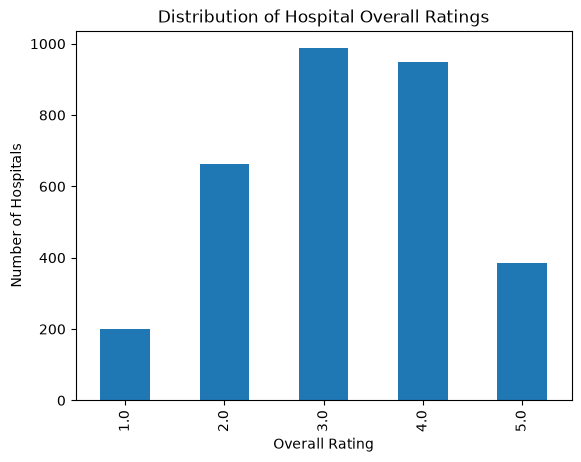

In [55]:
master_df["hospital_overall_rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Hospital Overall Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Hospitals")

plt.show()

# Hospital Characteristics

In [56]:
master_df["hospital_ownership"].value_counts()

hospital_ownership
Voluntary non-profit - Private                 2316
Proprietary                                    1067
Government - Hospital District or Authority     516
Government - Local                              397
Voluntary non-profit - Other                    355
Voluntary non-profit - Church                   268
Government - State                              209
Veterans Health Administration                  132
Physician                                        81
Government - Federal                             43
Department of Defense                            32
Tribal                                           16
Name: count, dtype: int64

In [57]:
master_df["hospital_type"].value_counts()

hospital_type
Acute Care Hospitals                    3115
Critical Access Hospitals               1378
Psychiatric                              635
Acute Care - Veterans Administration     132
Childrens                                 94
Rural Emergency Hospital                  41
Acute Care - Department of Defense        32
Long-term                                  5
Name: count, dtype: int64

# Geographic Exploration- Top 15 States

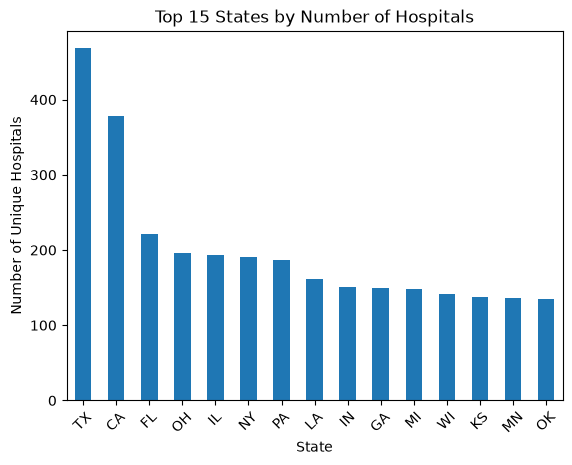

In [58]:
top_states = (
    master_df[["facility_id", "state"]]
    .drop_duplicates()
    ["state"]
    .value_counts()
    .head(15)
)

top_states.plot(kind="bar")

plt.title("Top 15 States by Number of Hospitals")
plt.xlabel("State")
plt.ylabel("Number of Unique Hospitals")
plt.xticks(rotation=45)
plt.show()

# Missing Values after Cleaning

In [59]:
master_df.isna().sum().sort_values(ascending=False).head(20)

hysterectomy_ssi_sir                                4828
cabg_readmit                                        4555
cabg_mortality                                      4547
te_group_footnote                                   4422
readm_group_footnote                                4208
mort_group_footnote                                 4032
hip_knee_readmit                                    3807
mrsa_sir                                            3704
colon_ssi_sir                                       3653
heart_attack_readmit                                3609
clabsi_sir                                          3484
heart_attack_mortality                              3480
pt_exp_group_footnote                               3414
safety_group_footnote                               3280
stroke_mortality                                    3219
cauti_sir                                           3192
meets_criteria_for_birthing_friendly_designation    3169
hospital_overall_rating_footnot

# Numerical Variable Summary

In [60]:
master_df.describe()

,zip_code,hospital_overall_rating,mort_group_measure_count,count_of_facility_mort_measures,count_of_mort_measures_better,count_of_mort_measures_no_different,count_of_mort_measures_worse,mort_group_footnote,safety_group_measure_count,count_of_facility_safety_measures,...,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality,heart_attack_readmit,cabg_readmit,copd_readmit,heart_failure_readmit,hip_knee_readmit,pneumonia_readmit
count,5432.000000,3182.000000,4578.0,4105.000000,4105.000000,4105.000000,4105.000000,1400.000000,4578.0,3354.000000,...,2656.000000,3102.000000,3642.000000,2213.000000,1823.000000,877.000000,2696.000000,3151.000000,1625.000000,3631.000000
mean,53822.804124,3.206788,8.0,4.846041,0.276736,4.419001,0.150305,14.710000,8.0,4.689624,...,8.874623,11.575403,16.352087,13.237732,13.631267,10.636146,18.228746,19.708918,4.856062,15.991600
std,27052.075419,1.094115,0.0,2.436858,0.813451,2.231777,0.464705,7.384772,0.0,2.465019,...,1.544256,2.180960,2.761638,1.701576,0.831124,1.023215,0.856853,1.216124,0.707091,0.975537
min,603.000000,1.000000,8.0,1.000000,0.000000,0.000000,0.000000,5.000000,8.0,1.000000,...,4.500000,5.000000,7.600000,8.100000,9.700000,7.800000,15.700000,14.300000,2.400000,12.700000
25%,32796.000000,2.000000,8.0,3.000000,0.000000,2.000000,0.000000,5.000000,8.0,2.000000,...,7.800000,10.100000,14.500000,12.100000,13.100000,9.900000,17.700000,19.000000,4.400000,15.400000
50%,55087.000000,3.000000,8.0,5.000000,0.000000,4.000000,0.000000,19.000000,8.0,5.000000,...,8.700000,11.500000,16.200000,13.100000,13.600000,10.600000,18.100000,19.600000,4.800000,15.900000
75%,76105.500000,4.000000,8.0,7.000000,0.000000,6.000000,0.000000,19.000000,8.0,7.000000,...,9.800000,12.900000,18.000000,14.200000,14.100000,11.300000,18.700000,20.400000,5.200000,16.500000
max,99929.000000,5.000000,8.0,8.000000,8.000000,8.000000,5.000000,29.000000,8.0,8.000000,...,16.500000,20.200000,32.200000,22.100000,16.800000,15.000000,23.900000,26.600000,7.800000,22.700000


# Correlations

In [61]:
numeric = master_df.select_dtypes(include="number")

corr = numeric.corr()

corr

,zip_code,hospital_overall_rating,mort_group_measure_count,count_of_facility_mort_measures,count_of_mort_measures_better,count_of_mort_measures_no_different,count_of_mort_measures_worse,mort_group_footnote,safety_group_measure_count,count_of_facility_safety_measures,...,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality,heart_attack_readmit,cabg_readmit,copd_readmit,heart_failure_readmit,hip_knee_readmit,pneumonia_readmit
zip_code,1.000000,0.028048,NaN,-0.137091,-0.075250,-0.112459,-0.047075,-0.128985,NaN,-0.071079,...,0.098365,0.038891,0.004697,0.054336,-0.042362,0.002410,-0.117034,-0.085113,-0.049377,-0.060850
hospital_overall_rating,0.028048,1.000000,NaN,-0.036911,0.300993,-0.107832,-0.290787,0.021530,NaN,0.003619,...,-0.299594,-0.295808,-0.461829,-0.307059,-0.252156,-0.305570,-0.253069,-0.362125,-0.274251,-0.286306
mort_group_measure_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_of_facility_mort_measures,-0.137091,-0.036911,NaN,1.000000,0.324011,0.928140,0.219258,-0.160174,NaN,0.812904,...,-0.017774,-0.154533,-0.171384,-0.078873,-0.056691,0.043802,0.024676,0.002218,0.124845,0.098855
count_of_mort_measures_better,-0.075250,0.300993,NaN,0.324011,1.000000,0.004163,-0.071386,-0.015791,NaN,0.318532,...,-0.377123,-0.493773,-0.463757,-0.350747,0.001143,-0.139477,0.007063,-0.105168,-0.043805,0.056909
count_of_mort_measures_no_different,-0.112459,-0.107832,NaN,0.928140,0.004163,1.000000,0.057203,-0.118702,NaN,0.692811,...,0.106970,-0.005437,-0.082256,0.074638,-0.045929,0.154262,0.014603,0.053495,0.147651,0.077173
count_of_mort_measures_worse,-0.047075,-0.290787,NaN,0.219258,-0.071386,0.057203,1.000000,-0.248848,NaN,0.154972,...,0.311863,0.361752,0.396440,0.278609,0.007651,-0.013874,0.016824,0.011297,0.012376,0.021295
mort_group_footnote,-0.128985,0.021530,NaN,-0.160174,-0.015791,-0.118702,-0.248848,1.000000,NaN,0.625742,...,-0.282711,-0.356595,-0.547433,-0.355149,-0.154795,-0.114460,0.014334,-0.109806,0.246861,-0.085379
safety_group_measure_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_of_facility_safety_measures,-0.071079,0.003619,NaN,0.812904,0.318532,0.692811,0.154972,0.625742,NaN,1.000000,...,-0.080151,-0.208732,-0.181878,-0.114775,-0.030619,-0.003585,0.037428,0.002486,0.139625,0.095791


## Initial Findings

- The merged dataset contains ____ hospitals.
- Hospital Overall Rating ranges from 1 to 5 stars.
- Most hospitals are classified as Acute Care.
- Missing values remain primarily in footnotes, measure-specific statistics such as score, lower_estimate, higher_estimate, denominator.
- Patient experience measures appear likely to contribute to predicting hospital quality.

In [62]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Numeric Columns",
        "Categorical Columns"
    ],
    "Value": [
        master_df.shape[0],
        master_df.shape[1],
        len(master_df.select_dtypes(include="number").columns),
        len(master_df.select_dtypes(exclude="number").columns),
    ]
})

display(summary)

,Metric,Value
0,Rows,5432
1,Columns,63
2,Numeric Columns,51
3,Categorical Columns,12


# Find Multiple Rows per Hospital

In [63]:
datasets = {
    "Hospital General": hospital_general,
    "HCAHPS": hcahps,
    "Infections": hospital_infections,
    "Mortality": hospital_mortality,
    "Readmissions": hospital_readmissions,
}

for name, df in datasets.items():

    print("=" * 60)
    print(name)

    print(f"Rows: {len(df):,}")

    print(f"Unique hospitals: {df['facility_id'].nunique():,}")

    print(f"Average rows per hospital: {len(df) / df['facility_id'].nunique():.2f}")

Hospital General
Rows: 5,432
Unique hospitals: 5,432
Average rows per hospital: 1.00
HCAHPS
Rows: 325,856
Unique hospitals: 4,792
Average rows per hospital: 68.00
Infections
Rows: 172,512
Unique hospitals: 4,792
Average rows per hospital: 36.00
Mortality
Rows: 95,840
Unique hospitals: 4,792
Average rows per hospital: 20.00
Readmissions
Rows: 67,088
Unique hospitals: 4,792
Average rows per hospital: 14.00


In [64]:
hcahps.columns.tolist()

['facility_id',
 'facility_name',
 'address',
 'city_town',
 'state',
 'zip_code',
 'county_parish',
 'telephone_number',
 'hcahps_measure_id',
 'hcahps_question',
 'hcahps_answer_description',
 'patient_survey_star_rating',
 'patient_survey_star_rating_footnote',
 'hcahps_answer_percent',
 'hcahps_answer_percent_footnote',
 'hcahps_linear_mean_value',
 'number_of_completed_surveys',
 'number_of_completed_surveys_footnote',
 'survey_response_rate_percent',
 'survey_response_rate_percent_footnote',
 'start_date',
 'end_date']

In [65]:
hcahps[hcahps["facility_id"] == hcahps["facility_id"].iloc[0]].head(15)

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hcahps_measure_id,hcahps_question,...,patient_survey_star_rating_footnote,hcahps_answer_percent,hcahps_answer_percent_footnote,hcahps_linear_mean_value,number_of_completed_surveys,number_of_completed_surveys_footnote,survey_response_rate_percent,survey_response_rate_percent_footnote,start_date,end_date
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,76.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
1,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,6.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
2,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,18.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
3,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_LINEAR_SCORE,Nurse communication - linear mean score,...,NaN,NaN,NaN,90.0,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
4,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_STAR_RATING,Nurse communication - star rating,...,NaN,NaN,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
5,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,86.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
6,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,3.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
7,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_RESPECT_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,11.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
8,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_LISTEN_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,71.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025
9,10001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_NURSE_LISTEN_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,7.0,NaN,NaN,952.0,NaN,17.0,NaN,7/1/2024,6/30/2025


# Save Final Dataset

In [69]:
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

master_df.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False,
)

print(master_df.shape)

(5432, 63)


In [70]:
print(master_df.info())
display(master_df.describe(include="all"))
display(master_df.isna().sum().sort_values(ascending=False).head(20))

<class 'pandas.DataFrame'>
RangeIndex: 5432 entries, 0 to 5431
Data columns (total 63 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   facility_id                                       5432 non-null   str    
 1   facility_name                                     5432 non-null   str    
 2   address                                           5432 non-null   str    
 3   city_town                                         5432 non-null   str    
 4   state                                             5432 non-null   str    
 5   zip_code                                          5432 non-null   int64  
 6   county_parish                                     5432 non-null   str    
 7   telephone_number                                  5432 non-null   str    
 8   hospital_type                                     5432 non-null   str    
 9   hospital_ownership            

,facility_id,facility_name,address,city_town,state,zip_code,county_parish,telephone_number,hospital_type,hospital_ownership,...,copd_mortality,heart_failure_mortality,pneumonia_mortality,stroke_mortality,heart_attack_readmit,cabg_readmit,copd_readmit,heart_failure_readmit,hip_knee_readmit,pneumonia_readmit
count,5432,5432,5432,5432,5432,5432.000000,5432,5432,5432,5432,...,2656.000000,3102.000000,3642.000000,2213.000000,1823.000000,877.000000,2696.000000,3151.000000,1625.000000,3631.000000
unique,5432,5301,5398,3048,56,NaN,1555,5393,8,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,10001,MEMORIAL HOSPITAL,100 HOSPITAL DRIVE,CHICAGO,TX,NaN,LOS ANGELES,(469) 341-7800,Acute Care Hospitals,Voluntary non-profit - Private,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,12,7,34,468,NaN,88,4,3115,2316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,53822.804124,NaN,NaN,NaN,NaN,...,8.874623,11.575403,16.352087,13.237732,13.631267,10.636146,18.228746,19.708918,4.856062,15.991600
std,NaN,NaN,NaN,NaN,NaN,27052.075419,NaN,NaN,NaN,NaN,...,1.544256,2.180960,2.761638,1.701576,0.831124,1.023215,0.856853,1.216124,0.707091,0.975537
min,NaN,NaN,NaN,NaN,NaN,603.000000,NaN,NaN,NaN,NaN,...,4.500000,5.000000,7.600000,8.100000,9.700000,7.800000,15.700000,14.300000,2.400000,12.700000
25%,NaN,NaN,NaN,NaN,NaN,32796.000000,NaN,NaN,NaN,NaN,...,7.800000,10.100000,14.500000,12.100000,13.100000,9.900000,17.700000,19.000000,4.400000,15.400000
50%,NaN,NaN,NaN,NaN,NaN,55087.000000,NaN,NaN,NaN,NaN,...,8.700000,11.500000,16.200000,13.100000,13.600000,10.600000,18.100000,19.600000,4.800000,15.900000
75%,NaN,NaN,NaN,NaN,NaN,76105.500000,NaN,NaN,NaN,NaN,...,9.800000,12.900000,18.000000,14.200000,14.100000,11.300000,18.700000,20.400000,5.200000,16.500000


hysterectomy_ssi_sir                                4828
cabg_readmit                                        4555
cabg_mortality                                      4547
te_group_footnote                                   4422
readm_group_footnote                                4208
mort_group_footnote                                 4032
hip_knee_readmit                                    3807
mrsa_sir                                            3704
colon_ssi_sir                                       3653
heart_attack_readmit                                3609
clabsi_sir                                          3484
heart_attack_mortality                              3480
pt_exp_group_footnote                               3414
safety_group_footnote                               3280
stroke_mortality                                    3219
cauti_sir                                           3192
meets_criteria_for_birthing_friendly_designation    3169
hospital_overall_rating_footnot

In [71]:
feature_checks = {
    "HCAHPS": [c for c in master_df.columns if c.endswith("_star")],
    "Infections": [c for c in master_df.columns if c.endswith("_sir")],
    "Mortality": [c for c in master_df.columns if c.endswith("_mortality")],
    "Readmissions": [c for c in master_df.columns if c.endswith("_readmit")],
}

for group, cols in feature_checks.items():
    print(f"\n{group} ({len(cols)}):")
    print(cols)


HCAHPS (7):
['cleanliness_star', 'nurse_comm_star', 'doctor_comm_star', 'medicine_comm_star', 'discharge_info_star', 'quietness_star', 'recommend_hospital_star']

Infections (6):
['clabsi_sir', 'cauti_sir', 'colon_ssi_sir', 'hysterectomy_ssi_sir', 'mrsa_sir', 'cdiff_sir']

Mortality (6):
['heart_attack_mortality', 'cabg_mortality', 'copd_mortality', 'heart_failure_mortality', 'pneumonia_mortality', 'stroke_mortality']

Readmissions (6):
['heart_attack_readmit', 'cabg_readmit', 'copd_readmit', 'heart_failure_readmit', 'hip_knee_readmit', 'pneumonia_readmit']
